In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import igraph as ig
from scipy.stats import entropy, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully")
print(f"igraph version: {ig.__version__}")

✓ All libraries imported successfully
igraph version: 0.11.9


Loaded connectivity matrix: 72 nodes
Matrix shape: (72, 72)

First few node labels:
  0: DG Granule
  1: DG Semilunar Granule
  2: DG Mossy
  3: DG AIPRIM
  4: DG Axo Axonic


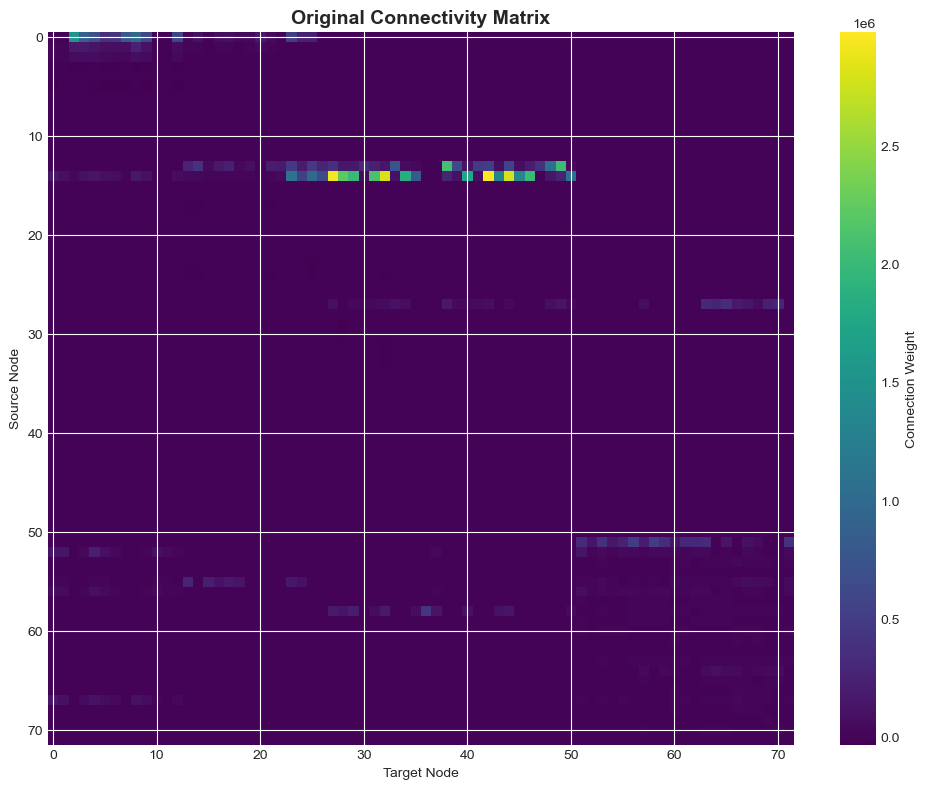

In [2]:
df = pd.read_csv('../data/w_ij_gaa.csv', index_col=0)

W = df.values
node_labels = df.columns.tolist()

print(f"Loaded connectivity matrix: {W.shape[0]} nodes")
print(f"Matrix shape: {W.shape}")
print(f"\nFirst few node labels:")
for i, label in enumerate(node_labels[:5]):
    print(f"  {i}: {label}")

# Display the connectivity matrix
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(W, cmap='viridis', aspect='auto')
ax.set_title('Original Connectivity Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Target Node')
ax.set_ylabel('Source Node')
plt.colorbar(im, ax=ax, label='Connection Weight')
plt.tight_layout()
plt.show()

---
## 6. Compute Centrality Measures

Calculate various centrality measures for edges in the edge network.

In [3]:
print("Computing centrality measures...")

# Calculate centralities
degree_centrality = np.array(G_edges.degree())
betweenness_centrality = np.array(G_edges.betweenness())
closeness_centrality = np.array(G_edges.closeness())
eigenvector_centrality = np.array(G_edges.eigenvector_centrality())
pagerank_centrality = np.array(G_edges.pagerank())

# Add to graph
G_edges.vs['degree'] = degree_centrality.tolist()
G_edges.vs['betweenness'] = betweenness_centrality.tolist()
G_edges.vs['closeness'] = closeness_centrality.tolist()
G_edges.vs['eigenvector'] = eigenvector_centrality.tolist()
G_edges.vs['pagerank'] = pagerank_centrality.tolist()

print("✓ Centrality measures computed")

# Summary statistics
print("\n" + "="*60)
print("CENTRALITY STATISTICS")
print("="*60)
print(f"Degree:      mean={degree_centrality.mean():.2f}, max={degree_centrality.max():.0f}")
print(f"Betweenness: mean={betweenness_centrality.mean():.2f}, max={betweenness_centrality.max():.2f}")
print(f"Closeness:   mean={closeness_centrality.mean():.4f}, max={closeness_centrality.max():.4f}")
print(f"Eigenvector: mean={eigenvector_centrality.mean():.4f}, max={eigenvector_centrality.max():.4f}")
print(f"PageRank:    mean={pagerank_centrality.mean():.6f}, max={pagerank_centrality.max():.6f}")

# Find most central edges
top_k = 10
print(f"\n{'='*60}")
print(f"TOP {top_k} EDGES BY BETWEENNESS CENTRALITY")
print("="*60)
top_idx = np.argsort(betweenness_centrality)[-top_k:]
for rank, idx in enumerate(reversed(top_idx), 1):
    print(f"{rank:2d}. {edge_labels[idx][:60]}")
    print(f"    Betweenness: {betweenness_centrality[idx]:.2f}, "
          f"Degree: {degree_centrality[idx]:.0f}, "
          f"Weight: {edge_weights_list[idx]:.2f}")

Computing centrality measures...


NameError: name 'G_edges' is not defined

### Visualize Centrality Distributions

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

centralities = [
    ('Degree', degree_centrality),
    ('Betweenness', betweenness_centrality),
    ('Closeness', closeness_centrality),
    ('Eigenvector', eigenvector_centrality),
    ('PageRank', pagerank_centrality)
]

for idx, (name, values) in enumerate(centralities):
    ax = axes[idx // 3, idx % 3]
    ax.hist(values, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(np.mean(values), color='red', linestyle='--', 
               linewidth=2, label=f'Mean={np.mean(values):.2e}')
    ax.set_xlabel(name)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{name} Distribution')
    ax.legend()
    ax.grid(alpha=0.3)

# Remove empty subplot
axes[1, 2].remove()

plt.tight_layout()
plt.show()

---
## 7. Community Detection

Detect communities in the edge network. Edge communities can reveal overlapping functional modules.

In [ ]:
print("Testing community detection methods...\n")

methods = ['multilevel', 'leiden', 'infomap', 'label_propagation']
results = {}

for method in methods:
    try:
        if method == 'multilevel':
            communities = G_edges.community_multilevel()
        elif method == 'leiden':
            communities = G_edges.community_leiden()
        elif method == 'infomap':
            communities = G_edges.community_infomap()
        elif method == 'label_propagation':
            communities = G_edges.community_label_propagation()
        
        results[method] = communities
        print(f"{method:20s}: {len(communities):3d} communities, "
              f"Q={communities.modularity:.4f}, "
              f"sizes={[len(c) for c in communities][:5]}...")
    except Exception as e:
        print(f"{method:20s}: Not available - {e}")

# Use the method with highest modularity
best_method = max(results.items(), key=lambda x: x[1].modularity)
communities = best_method[1]

print(f"\n✓ Using {best_method[0]} (highest modularity)")

# Add community assignments to graph
G_edges.vs['community'] = communities.membership

print("\n" + "="*60)
print("COMMUNITY DETECTION RESULTS")
print("="*60)
print(f"Method: {best_method[0]}")
print(f"Number of communities: {len(communities)}")
print(f"Modularity: {communities.modularity:.4f}")
print(f"Community sizes: {[len(c) for c in communities]}")

### Analyze Community Structure

In [ ]:
# Analyze which original nodes are involved in each edge community
print("\n" + "="*60)
print("EDGE COMMUNITIES → ORIGINAL NODES")
print("="*60)

for comm_idx, community in enumerate(communities):
    if len(community) < 3:  # Skip very small communities
        continue
    
    # Get all original nodes involved in this edge community
    nodes_in_community = set()
    for edge_idx in community:
        source = edge_nodes[edge_idx][0]
        target = edge_nodes[edge_idx][1]
        nodes_in_community.add(source)
        nodes_in_community.add(target)
    
    print(f"\nCommunity {comm_idx} ({len(community)} edges, "
          f"{len(nodes_in_community)} unique nodes):")
    
    # Sample nodes
    node_names = [node_labels[n] for n in list(nodes_in_community)[:8]]
    print(f"  Sample nodes: {', '.join(node_names[:5])}")
    if len(node_names) > 5:
        print(f"                {', '.join(node_names[5:8])}...")
    
    # Most connected edges in this community
    edges_in_comm = [(edge_labels[i], degree_centrality[i]) for i in community]
    edges_in_comm.sort(key=lambda x: x[1], reverse=True)
    print(f"  Most connected edge: {edges_in_comm[0][0][:55]}")
    print(f"                       (degree={edges_in_comm[0][1]:.0f})")

### Visualize Edge FC Matrix Ordered by Communities

In [ ]:
# Reorder matrix by communities
community_order = np.argsort(communities.membership)
eFC_reordered = eFC[community_order, :][:, community_order]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Original order
ax = axes[0]
im = ax.imshow(eFC, cmap='binary', aspect='auto')
ax.set_title('Edge FC Matrix (original order)', fontsize=12, fontweight='bold')
ax.set_xlabel('Edge Index')
ax.set_ylabel('Edge Index')
plt.colorbar(im, ax=ax, label='Connected')

# Ordered by communities
ax = axes[1]
im = ax.imshow(eFC_reordered, cmap='binary', aspect='auto')
ax.set_title(f'Edge FC Matrix (ordered by {len(communities)} communities)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Edge Index')
ax.set_ylabel('Edge Index')

# Add community boundaries
boundaries = [0]
for c in communities:
    boundaries.append(boundaries[-1] + len(c))
for b in boundaries[1:-1]:
    ax.axhline(b, color='red', linewidth=1, alpha=0.6)
    ax.axvline(b, color='red', linewidth=1, alpha=0.6)

plt.colorbar(im, ax=ax, label='Connected')
plt.tight_layout()
plt.show()

print(f"✓ Communities show block-diagonal structure (modularity = {communities.modularity:.4f})")

---
## 8. Project Communities to Nodes (Overlapping Communities)

Edge communities can be projected back onto nodes, creating overlapping node communities.

In [ ]:
# Calculate node participation in each edge community
n_communities = len(communities)
participation = np.zeros((n_nodes, n_communities))

# Count how many edges in each community connect to each node
for edge_idx, (source, target) in enumerate(edge_nodes):
    comm = communities.membership[edge_idx]
    participation[source, comm] += 1
    participation[target, comm] += 1

# Normalize by total edges per node
row_sums = participation.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1  # Avoid division by zero
participation = participation / row_sums

print("="*60)
print("NODE PARTICIPATION IN EDGE COMMUNITIES")
print("="*60)
print(f"Participation matrix shape: {participation.shape}")
print(f"(nodes × communities)")

# Calculate overlap (entropy)
node_entropy = np.array([entropy(p) for p in participation])

# Nodes with highest overlap
top_overlap = 10
high_overlap_idx = np.argsort(node_entropy)[-top_overlap:]

print(f"\nTop {top_overlap} nodes with highest community overlap:")
for rank, idx in enumerate(reversed(high_overlap_idx), 1):
    # Get top communities for this node
    top_comms = np.argsort(participation[idx])[-3:]
    comm_str = ", ".join([f"C{c}({participation[idx,c]:.2f})" for c in reversed(top_comms)])
    print(f"{rank:2d}. {node_labels[idx]:40s} entropy={node_entropy[idx]:.3f} [{comm_str}]")

# Visualize participation matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Participation matrix
ax = axes[0]
im = ax.imshow(participation, cmap='YlOrRd', aspect='auto')
ax.set_title('Node Participation in Edge Communities', fontsize=12, fontweight='bold')
ax.set_xlabel('Community')
ax.set_ylabel('Node')
plt.colorbar(im, ax=ax, label='Participation')

# Node entropy distribution
ax = axes[1]
ax.hist(node_entropy, bins=30, edgecolor='black', alpha=0.7, color='coral')
ax.axvline(node_entropy.mean(), color='red', linestyle='--', 
           linewidth=2, label=f'Mean={node_entropy.mean():.3f}')
ax.set_xlabel('Entropy (overlap)')
ax.set_ylabel('Number of Nodes')
ax.set_title('Distribution of Node Community Overlap', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 9. Network Visualization

Visualize the edge network (using largest connected component for clarity).

In [ ]:
# Get largest component for visualization
components = G_edges.components()
largest_comp = max(components, key=len)
G_vis = G_edges.subgraph(largest_comp)

print(f"Visualizing largest component: {len(largest_comp)} / {G_edges.vcount()} nodes")

# Calculate layout (this may take a moment for large networks)
print("Computing network layout...")
layout = G_vis.layout_fruchterman_reingold()
print("✓ Layout computed")

# Prepare visualization attributes
colors_community = [communities.membership[i] for i in largest_comp]
sizes_betweenness = [G_vis.vs[i]['betweenness'] for i in range(len(G_vis.vs))]
max_between = max(sizes_betweenness) if max(sizes_betweenness) > 0 else 1
vertex_sizes = [5 + 25 * (b / max_between) for b in sizes_betweenness]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Plot 1: Colored by community
ax = axes[0]
ig.plot(
    G_vis,
    target=ax,
    layout=layout,
    vertex_size=12,
    vertex_color=colors_community,
    vertex_frame_width=0.5,
    edge_width=0.3,
    edge_color='#CCCCCC',
    palette=ig.RainbowPalette(n=len(communities))
)
ax.set_title(f'Edge Network - Colored by Community\n'
             f'(Largest Component: {len(largest_comp)} edges, '
             f'{len(communities)} communities)',
             fontsize=12, fontweight='bold')
ax.axis('off')

# Plot 2: Sized by betweenness centrality
ax = axes[1]

# Label high-importance edges
betweenness_threshold = np.percentile(sizes_betweenness, 95)
labels = [G_vis.vs[i]['name'][:25] if sizes_betweenness[i] > betweenness_threshold 
          else '' for i in range(len(G_vis.vs))]

ig.plot(
    G_vis,
    target=ax,
    layout=layout,
    vertex_size=vertex_sizes,
    vertex_color='lightblue',
    vertex_frame_color='navy',
    vertex_frame_width=0.5,
    vertex_label=labels,
    vertex_label_size=7,
    edge_width=0.3,
    edge_color='#CCCCCC'
)
ax.set_title(f'Edge Network - Sized by Betweenness Centrality\n'
             f'(Largest Component: {len(largest_comp)} edges)',
             fontsize=12, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

print("\n✓ Network visualization complete")

---
## 10. Summary Statistics

Create a comprehensive DataFrame with all edge statistics.

In [ ]:
# Create comprehensive statistics DataFrame
stats_df = pd.DataFrame({
    'edge_label': edge_labels,
    'source_node': [node_labels[e[0]] for e in edge_nodes],
    'target_node': [node_labels[e[1]] for e in edge_nodes],
    'source_idx': [e[0] for e in edge_nodes],
    'target_idx': [e[1] for e in edge_nodes],
    'original_weight': edge_weights_list,
    'degree': degree_centrality,
    'betweenness': betweenness_centrality,
    'closeness': closeness_centrality,
    'eigenvector': eigenvector_centrality,
    'pagerank': pagerank_centrality,
    'community': communities.membership
})

# Sort by betweenness
stats_df = stats_df.sort_values('betweenness', ascending=False)

print("="*60)
print("EDGE STATISTICS SUMMARY")
print("="*60)
print(f"Total edges analyzed: {len(stats_df)}")
print(f"\nTop 20 edges by betweenness centrality:")
print(stats_df.head(20)[['edge_label', 'betweenness', 'degree', 'community']])

# Save to file (optional)
# stats_df.to_csv('edge_statistics.csv', index=False)
# print("\n✓ Statistics saved to 'edge_statistics.csv'")